<h2 style="text-align: center; color: green;">Automated Model Monitoring & Alerting</h2>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#### Objective

This notebook demonstrates an automated model monitoring workflow using Population Stability Index (PSI) and Characteristic Stability Index (CSI).

The monitoring process analyzes the reference and test datasets to identify potential distribution drift, compares the calculated PSI and CSI values against predefined drift thresholds, determines the overall monitoring status, and generates an alert when significant drift is detected.

#### Drift Thresholds

The monitoring thresholds used in this workflow are:

- **PSI < 0.10:** No significant drift
- **0.10 ≤ PSI < 0.20:** Moderate drift
- **PSI ≥ 0.20:** Significant drift

For CSI, the same threshold interpretation is applied:

- **CSI < 0.10:** No significant drift
- **0.10 ≤ CSI < 0.20:** Moderate drift
- **CSI ≥ 0.20:** Significant drift

#### PSI Monitoring

Population Stability Index (PSI) is used to monitor changes in the distribution of model prediction probabilities between the reference and test datasets.

In [2]:
df_reference_probabilities = pd.read_csv("data/train_probabilities.csv")
df_test_probabilities = pd.read_csv("data/test_probabilities.csv")

In [3]:
df_reference_probabilities.columns = ['probability']
df_test_probabilities.columns = ['probability']

In [4]:
df_reference_probabilities.shape

(68390, 1)

In [5]:
df_test_probabilities.shape

(12497, 1)

In [6]:
reference_probabilities = df_reference_probabilities['probability'].to_numpy()
reference_probabilities

array([1.70220986e-04, 5.49840800e-06, 1.40608029e-03, ...,
       5.79523819e-01, 9.85969381e-01, 5.45847082e-01], shape=(68390,))

In [7]:
test_probabilities = df_test_probabilities['probability'].to_numpy()
test_probabilities

array([5.30387738e-01, 1.13741471e-05, 5.51618053e-03, ...,
       2.30195207e-03, 8.36266471e-01, 5.87664994e-01], shape=(12497,))

In [8]:
# Create 10 Bins Using Reference Probabilities

reference_bins = np.percentile(reference_probabilities,np.arange(0, 101, 10))

reference_bins_labels = range(1, 11)

reference_binned = pd.cut(reference_probabilities,bins=reference_bins,labels=reference_bins_labels,include_lowest=True)

In [9]:
# Calculate Reference Percentage for Each Bin

reference_bin_percentages = (pd.Series(reference_binned).value_counts(normalize=True).sort_index())

In [10]:
# Apply the Same Bin Cutoffs to Test Probabilities

test_binned = pd.cut(test_probabilities,bins=reference_bins,labels=reference_bins_labels,include_lowest=True)

In [11]:
# Calculate Test Percentage for Each Bin

test_bin_percentages = (pd.Series(test_binned).value_counts(normalize=True).sort_index())

In [12]:
# Calculate PSI Contribution for Each Bin

psi_by_bin = ((reference_bin_percentages - test_bin_percentages)* np.log(reference_bin_percentages / test_bin_percentages))

In [13]:
# Calculate Total PSI

psi = psi_by_bin.sum()
print(f"PSI: {psi:.4f}")

PSI: 0.7537


#### PSI Threshold Evaluation

The calculated PSI value is evaluated against the predefined thresholds to automatically determine the level of prediction distribution drift.

In [14]:
# Evaluate PSI Drift Level

if psi < 0.10:
    psi_status = "No significant drift"
elif psi < 0.20:
    psi_status = "Moderate drift"
else:
    psi_status = "Significant drift"

print(f"PSI: {psi:.4f}")
print(f"PSI Status: {psi_status}")

PSI: 0.7537
PSI Status: Significant drift


#### CSI Monitoring

Characteristic Stability Index (CSI) is used to monitor changes in the distribution of individual features between the reference and test datasets.

The CSI calculation is performed separately for numerical and categorical features, using the reference data as the baseline for comparison.

In [15]:
# Load reference and test feature data

df_reference_features = pd.read_csv("data/train_data.csv")
df_test_features = pd.read_csv("data/test_data.csv")

In [16]:
# Define Features for CSI Monitoring

selected_features = ["age","residence_type","loan_purpose","loan_type","loan_tenure_months","number_of_open_accounts","credit_utilization_ratio","loan_to_income","delinquency_ratio","avg_dpd_per_delinquency"]

numerical_features = (df_reference_features[selected_features].select_dtypes(include=["number"]).columns.tolist())

categorical_features = (df_reference_features[selected_features].select_dtypes(include=["object"]).columns.tolist())

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['age', 'loan_tenure_months', 'number_of_open_accounts', 'credit_utilization_ratio', 'loan_to_income', 'delinquency_ratio', 'avg_dpd_per_delinquency']

Categorical features:
['residence_type', 'loan_purpose', 'loan_type']


In [17]:
# Calculate CSI for Numerical Features

def calculate_numeric_csi(reference, test, bins=10):
    unique_values = reference.nunique()
    if unique_values < bins:
        reference_distribution = (reference.value_counts(normalize=True).sort_index())
        test_distribution = (test.value_counts(normalize=True).sort_index())

        reference_distribution, test_distribution = (reference_distribution.align(test_distribution,fill_value=0))

    else:
        reference_bins = pd.qcut(reference,q=bins,duplicates="drop")
        reference_distribution = (reference_bins.value_counts(normalize=True, sort=False))
        bin_edges = reference_bins.cat.categories
        test_bins = pd.cut(test,bins=bin_edges)
        test_distribution = (test_bins.value_counts(normalize=True, sort=False))

    reference_distribution = reference_distribution.replace(0, 1e-10)
    test_distribution = test_distribution.replace(0, 1e-10)

    csi = ((reference_distribution - test_distribution)* np.log(reference_distribution / test_distribution))
    return csi.sum()

In [18]:
# Calculate CSI for All Numerical Features

numeric_csi = {}

for feature in numerical_features:

    numeric_csi[feature] = calculate_numeric_csi(df_reference_features[feature],df_test_features[feature])

for feature, csi in numeric_csi.items():
    print(f"{feature:<30} {csi:.4f}")

age                            0.0671
loan_tenure_months             0.0421
number_of_open_accounts        0.0001
credit_utilization_ratio       0.0076
loan_to_income                 0.0015
delinquency_ratio              0.0010
avg_dpd_per_delinquency        0.0249


In [19]:
# Calculate CSI for Categorical Features

categorical_csi_details = {}
categorical_csi_totals = {}

for feature in categorical_features:
    # Reference distribution
    reference_distribution = (df_reference_features[feature].value_counts(normalize=True))

    # Test distribution using the same categories
    test_distribution = (df_test_features[feature].value_counts(normalize=True).reindex(reference_distribution.index, fill_value=0))

    # Prevent division by zero during CSI calculation
    reference_distribution = reference_distribution.replace(0, 1e-10)
    test_distribution = test_distribution.replace(0, 1e-10)

    # CSI contribution for each category
    csi_contribution = ((reference_distribution - test_distribution)* np.log(reference_distribution / test_distribution))

    # Store category-level CSI
    categorical_csi_details[feature] = csi_contribution

    # Store total CSI for the feature
    categorical_csi_totals[feature] = csi_contribution.sum()

In [20]:
# Display Categorical CSI Results

for feature, csi_values in categorical_csi_details.items():
    print(feature)
    print("-" * len(feature))
    for category, csi in csi_values.items():
        print(f"{category:<12} {csi:.6f}")

    print()

residence_type
--------------
Owned        0.000042
Mortgage     0.000001
Rented       0.000149

loan_purpose
------------
Personal     0.000005
Home         0.000048
Auto         0.000000
Education    0.000154

loan_type
---------
Secured      0.000003
Unsecured    0.000005



In [21]:
# Create CSI Summary

# Create numerical CSI DataFrame
numeric_csi_df = pd.DataFrame(list(numeric_csi.items()),columns=["Feature", "CSI"])

# Create categorical CSI DataFrame
categorical_csi_df = pd.DataFrame(list(categorical_csi_totals.items()),columns=["Feature", "CSI"])

# Combine numerical and categorical CSI results
csi_summary = pd.concat([numeric_csi_df, categorical_csi_df],ignore_index=True)

# Round CSI values
csi_summary["CSI"] = csi_summary["CSI"].round(4)

# Sort from highest to lowest CSI
csi_summary = (csi_summary.sort_values(by="CSI", ascending=False).reset_index(drop=True))

csi_summary

,Feature,CSI
0,age,0.0671
1,loan_tenure_months,0.0421
2,avg_dpd_per_delinquency,0.0249
3,credit_utilization_ratio,0.0076
4,loan_to_income,0.0015
5,delinquency_ratio,0.0010
6,loan_purpose,0.0002
7,residence_type,0.0002
8,number_of_open_accounts,0.0001
9,loan_type,0.0000


#### CSI Threshold Evaluation

The calculated CSI values are evaluated against the predefined thresholds to automatically determine the level of distribution drift for each feature.

In [22]:
# Evaluate CSI Drift Level

def classify_csi(csi):
    if csi < 0.10:
        return "No significant drift"
    elif csi < 0.20:
        return "Moderate drift"
    else:
        return "Significant drift"

csi_summary["Status"] = csi_summary["CSI"].apply(classify_csi)
csi_summary

,Feature,CSI,Status
0,age,0.0671,No significant drift
1,loan_tenure_months,0.0421,No significant drift
2,avg_dpd_per_delinquency,0.0249,No significant drift
3,credit_utilization_ratio,0.0076,No significant drift
4,loan_to_income,0.0015,No significant drift
5,delinquency_ratio,0.0010,No significant drift
6,loan_purpose,0.0002,No significant drift
7,residence_type,0.0002,No significant drift
8,number_of_open_accounts,0.0001,No significant drift
9,loan_type,0.0000,No significant drift


#### Overall Monitoring Status

The PSI and CSI results are combined to determine the overall monitoring status.

In [24]:
# Determine Overall Monitoring Status

if psi < 0.10:
    psi_status = "No significant drift"
elif psi < 0.20:
    psi_status = "Moderate drift"
else:
    psi_status = "Significant drift"


if (csi_summary["CSI"] >= 0.20).any():
    csi_status = "Significant drift"
elif (csi_summary["CSI"] >= 0.10).any():
    csi_status = "Moderate drift"
else:
    csi_status = "No significant drift"

if (
    psi_status == "Significant drift"
    or csi_status == "Significant drift"
):
    overall_status = "Significant drift detected"
else:
    overall_status = "No significant drift detected"

print(f"PSI Status: {psi_status}")
print(f"CSI Status: {csi_status}")
print(f"Overall Monitoring Status: {overall_status}")

PSI Status: Significant drift
CSI Status: No significant drift
Overall Monitoring Status: Significant drift detected


#### Monitoring Alert

An alert is generated when significant drift is detected in either the prediction probabilities or the monitored feature distributions.

In [25]:
# Generate Monitoring Alert

if overall_status == "Significant drift detected":
    alert_status = "ALERT"
    print("ALERT: Significant drift detected. Further investigation is required.")
else:
    alert_status = "NO ALERT"
    print("NO ALERT: No significant drift detected.")

ALERT: Significant drift detected. Further investigation is required.


#### Final Monitoring Summary

The final monitoring summary presents the PSI status, CSI status, overall monitoring status, and alert status generated from the automated monitoring workflow.

In [26]:
# Final Monitoring Summary

monitoring_summary = pd.DataFrame({
    "Metric": ["PSI Status","CSI Status","Overall Monitoring Status","Alert Status"],
    "Result": [psi_status,csi_status,overall_status,alert_status]
})

monitoring_summary

,Metric,Result
0,PSI Status,Significant drift
1,CSI Status,No significant drift
2,Overall Monitoring Status,Significant drift detected
3,Alert Status,ALERT


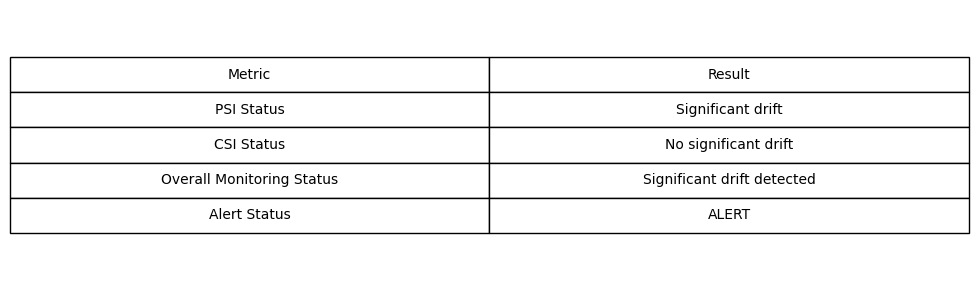

In [27]:
monitoring_display = monitoring_summary.copy()

# Create figure
fig, ax = plt.subplots(figsize=(10, 3))
ax.axis("off")
table = ax.table(cellText=monitoring_display.values,colLabels=monitoring_display.columns,cellLoc="center",loc="center")

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.3, 1.8)

plt.tight_layout()

# Save image
plt.savefig("images/automated_model_monitoring_and_alerting.png",dpi=300,bbox_inches="tight")
plt.show()